# Статистический анализ двух бинарных выборок

## 📊 Условие задачи

### Исходные данные:
- **Две бинарные выборки** с вероятностями успеха:
  - $p_1 = 0.35$ (первая выборка)
  - $p_2 = 0.40$ (вторая выборка)
- **Уровень значимости**: $\alpha = 0.05$ (p-value)
- **Минимальный детектируемый эффект (MDE)**: $\delta = |p_2 - p_1| = 0.05$

### Поставленные задачи:

#### 1. 📈 Определение минимального размера выборки
**Цель**: Найти минимальное количество элементов $n$ в каждой выборке, необходимое для детекции MDE с заданной мощностью теста ($1 - \beta = 0.8$).

**Формула для расчета**:
$$
n = \frac{(z_{1-\alpha/2} \cdot \sqrt{2 \cdot \bar{p} \cdot (1-\bar{p})} + z_{1-\beta} \cdot \sqrt{p_1(1-p_1) + p_2(1-p_2)})^2}{(p_1 - p_2)^2}
$$

где:
- $\bar{p} = \frac{p_1 + p_2}{2}$ - объединенная пропорция
- $z_{1-\alpha/2}$ - квантиль нормального распределения для двустороннего теста
- $z_{1-\beta}$ - квантиль нормального распределения для мощности теста

#### 2. 🔄 Преобразование распределений через ЦПТ
**Цель**: Используя Центральную Предельную Теорему (ЦПТ), преобразовать биномиальные распределения к нормальным.

**Формулы преобразования**:
- Для выборки размера $n$ с вероятностью $p$:
  $$
  \text{Среднее: } \mu = p
  $$
  $$
  \text{Стандартное отклонение: } \sigma = \sqrt{\frac{p(1-p)}{n}}
  $$
- Получаем нормальные распределения:
  - Первая выборка: $N(\mu_1, \sigma_1)$
  - Вторая выборка: $N(\mu_2, \sigma_2)$

#### 3. 📊 Визуализация распределений и ошибок
**Требуется построить два графика**:

**График 1**: Двусторонняя альтернатива
- Распределения обеих выборок
- Критические области для ошибки I рода ($\alpha$)
- Область ошибки II рода ($\beta$)

**График 2**: Односторонняя альтернатива ($p_1 > p_2$)
- Распределения обеих выборок  
- Односторонние критические области
- Соответствующие области ошибок

**Обозначения на графиках**:
- 🟦 **Синяя область** - Ошибка I рода (вероятность $\alpha$)
- 🟥 **Красная область** - Ошибка II рода (вероятность $\beta$)
- 📍 **Вертикальные линии** - Критические значения и средние

#### 4. 📐 Расчет доверительных интервалов
**Цель**: Построить $95\%$ доверительные интервалы для средних значений обеих выборок.

**Формула доверительного интервала**:
$$
CI = \hat{p} \pm z_{1-\alpha/2} \cdot \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}
$$

где:
- $\hat{p}$ - выборочная пропорция
- $z_{1-\alpha/2}$ - квантиль стандартного нормального распределения

### 🎯 Ожидаемые результаты:

1. **Числовой результат**: Минимальный размер выборки $n$
2. **Параметры распределений**: $\mu_1, \sigma_1, \mu_2, \sigma_2$
3. **Визуализация**: Два графика с областями статистических ошибок
4. **Интервальные оценки**: Доверительные интервалы для $p_1$ и $p_2$

### 📈 Статистические гипотезы:

**Для двустороннего теста**:
$$
H_0: p_1 = p_2 \\
H_1: p_1 \neq p_2
$$

**Для одностороннего теста**:
$$
H_0: p_1 \leq p_2 \\
H_1: p_1 > p_2
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import math

In [2]:
p1 = 0.35
p2 = 0.40
alpha = 0.05
power = 0.8
beta = 1 - power

In [3]:
print("=" * 53)
print("АНАЛИЗ ДВУХ БИНАРНЫХ ВЫБОРОК (С НЕРАВНЫМИ РАЗМЕРАМИ)")
print("=" * 53)
print(f"Вероятность в группе 1: {p1}")
print(f"Вероятность в группе 2: {p2}")
print(f"Уровень значимости (p-value): {alpha}")
print(f"Мощность теста: {power}")
print("-" * 53)

print("\n1. МИНИМАЛЬНЫЙ РАЗМЕР ВЫБОРКИ (РАВНЫЕ ГРУППЫ):")

z_alpha_2 = stats.norm.ppf(1 - alpha/2)
z_beta = stats.norm.ppf(1 - beta)
p_bar = (p1 + p2) / 2

n = ((z_alpha_2 * math.sqrt(2 * p_bar * (1 - p_bar)) +
            z_beta * math.sqrt(p1 * (1 - p1) + p2 * (1 - p2)))**2) / ((p1 - p2)**2)
n = math.ceil(n)

print(f"\nn₁ = n₂ = {n} элементов в каждой группе")

АНАЛИЗ ДВУХ БИНАРНЫХ ВЫБОРОК (С НЕРАВНЫМИ РАЗМЕРАМИ)
Вероятность в группе 1: 0.35
Вероятность в группе 2: 0.4
Уровень значимости (p-value): 0.05
Мощность теста: 0.8
-----------------------------------------------------

1. МИНИМАЛЬНЫЙ РАЗМЕР ВЫБОРКИ (РАВНЫЕ ГРУППЫ):

n₁ = n₂ = 1471 элементов в каждой группе


In [4]:
print("\n2. ПРЕОБРАЗОВАНИЕ ЧЕРЕЗ ЦПТ:")

sigma1_equal = math.sqrt(p1 * (1 - p1) / n)
sigma2_equal = math.sqrt(p2 * (1 - p2) / n)

print(f"\nРАВНЫЕ ВЫБОРКИ (n = {n}):")
print(f"Группа 1: N(μ = {p1:.4f}, σ = {sigma1_equal:.4f})")
print(f"Группа 2: N(μ = {p2:.4f}, σ = {sigma2_equal:.4f})")

n1_unequal = n // 2
n2_unequal = n1_unequal * 10

sigma1_unequal = math.sqrt(p1 * (1 - p1) / n1_unequal)
sigma2_unequal = math.sqrt(p2 * (1 - p2) / n2_unequal)

print(f"\nНЕРАВНЫЕ ВЫБОРКИ (n₁ = {n1_unequal}, n₂ = {n2_unequal}):")
print(f"Группа 1: N(μ = {p1:.4f}, σ = {sigma1_unequal:.4f})")
print(f"Группа 2: N(μ = {p2:.4f}, σ = {sigma2_unequal:.4f})")


2. ПРЕОБРАЗОВАНИЕ ЧЕРЕЗ ЦПТ:

РАВНЫЕ ВЫБОРКИ (n = 1471):
Группа 1: N(μ = 0.3500, σ = 0.0124)
Группа 2: N(μ = 0.4000, σ = 0.0128)

НЕРАВНЫЕ ВЫБОРКИ (n₁ = 735, n₂ = 7350):
Группа 1: N(μ = 0.3500, σ = 0.0176)
Группа 2: N(μ = 0.4000, σ = 0.0057)



3. Двусторонняя альтернатива


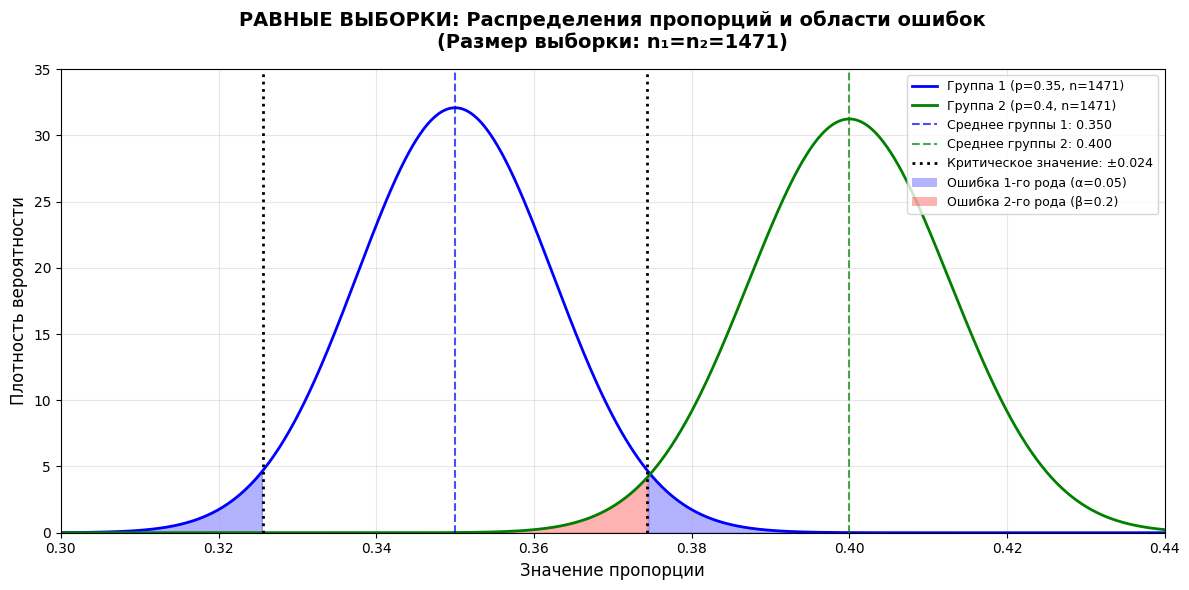

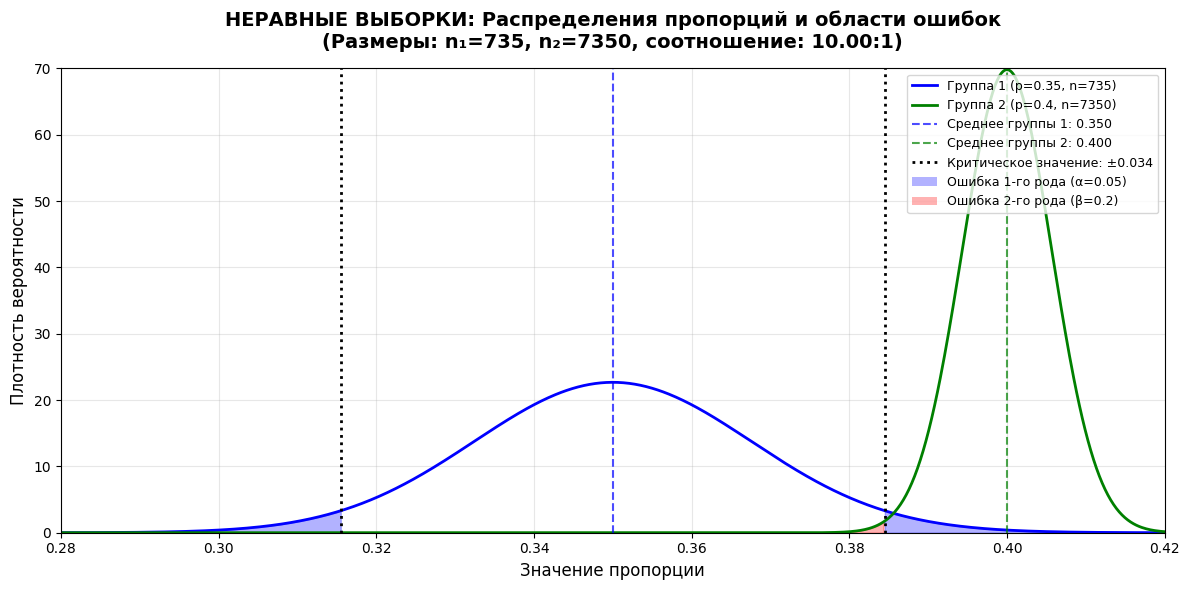


Односторонняя альтернатива


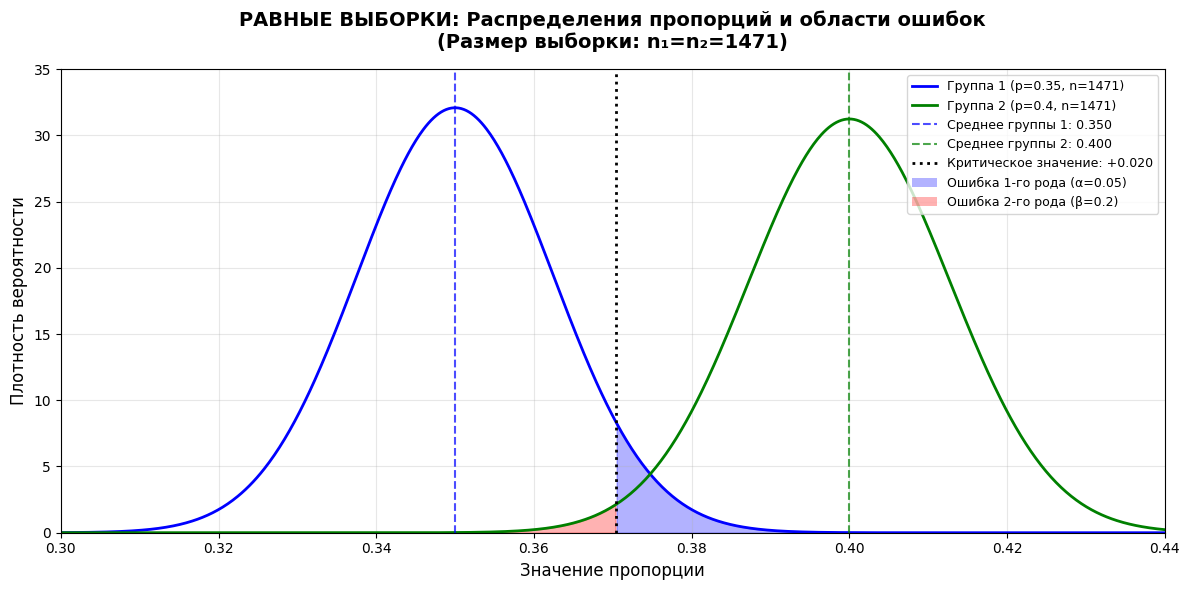

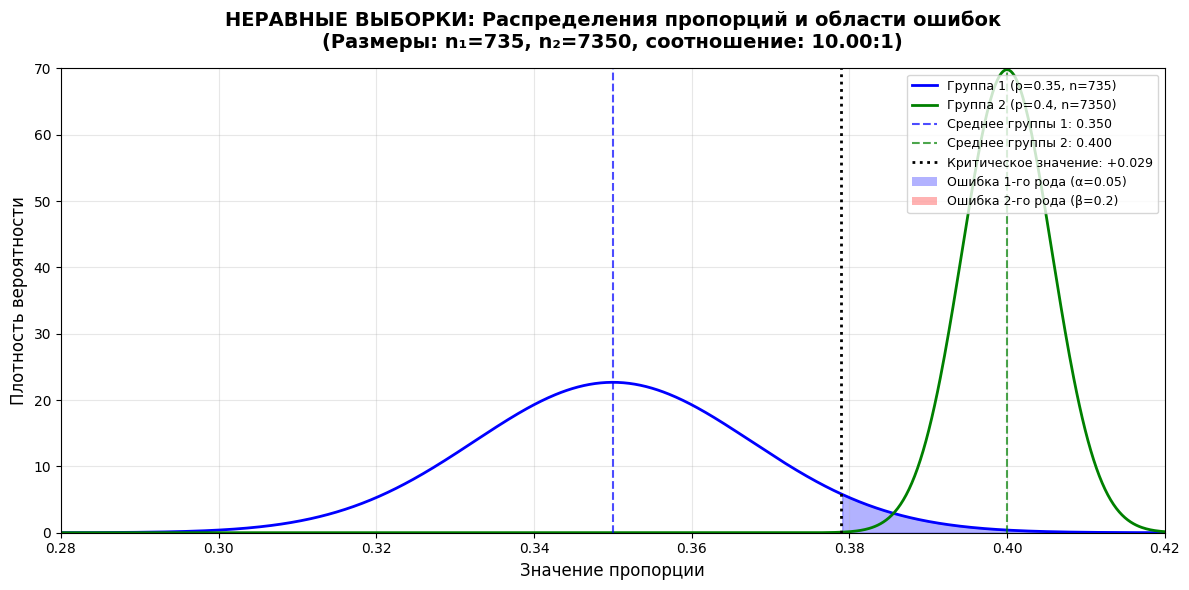

In [5]:
print("\n3. Двусторонняя альтернатива")

z_two_sided = stats.norm.ppf(1 - alpha/2)
z_one_sided = stats.norm.ppf(1 - alpha)

crit_two_equal = z_two_sided * sigma1_equal
crit_one_equal = z_one_sided * sigma1_equal
crit_two_unequal = z_two_sided * sigma1_unequal
crit_one_unequal = z_one_sided * sigma1_unequal

def create_plot(n1, n2, sigma1, sigma2, crit_value, title, is_two_sided=True):
    if n1 == n2:
        x = np.linspace(0.28, 0.44, 1000)
        xlims = (0.30, 0.44)
        ylims = (0, 35)
    else:
        x = np.linspace(0.26, 0.44, 1000)
        xlims = (0.28, 0.42)
        ylims = (0, 70)

    pdf1 = stats.norm.pdf(x, p1, sigma1)
    pdf2 = stats.norm.pdf(x, p2, sigma2)

    if is_two_sided:
        crit_left = p1 - crit_value
        crit_right = p1 + crit_value
        crit_text = f'±{crit_value:.3f}'
    else:
        crit_left = -np.inf
        crit_right = p1 + crit_value
        crit_text = f'+{crit_value:.3f}'

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(x, pdf1, 'b-', linewidth=2, label=f'Группа 1 (p={p1}, n={n1})')
    ax.plot(x, pdf2, 'g-', linewidth=2, label=f'Группа 2 (p={p2}, n={n2})')

    if is_two_sided:
        mask_alpha_left = x < crit_left
        mask_alpha_right = x > crit_right
        ax.fill_between(x, 0, pdf1, where=mask_alpha_left, alpha=0.3, color='blue')
        ax.fill_between(x, 0, pdf1, where=mask_alpha_right, alpha=0.3, color='blue')
        mask_beta = (x >= crit_left) & (x <= crit_right)
        ax.fill_between(x, 0, pdf2, where=mask_beta, alpha=0.3, color='red')
        ax.axvline(crit_left, color='black', linestyle=':', linewidth=2)
        ax.axvline(crit_right, color='black', linestyle=':', linewidth=2)
    else:
        mask_alpha = x > crit_right
        ax.fill_between(x, 0, pdf1, where=mask_alpha, alpha=0.3, color='blue')
        mask_beta = x < crit_right
        ax.fill_between(x, 0, pdf2, where=mask_beta, alpha=0.3, color='red')
        ax.axvline(crit_right, color='black', linestyle=':', linewidth=2)

    ax.axvline(p1, color='blue', linestyle='--', alpha=0.7)
    ax.axvline(p2, color='green', linestyle='--', alpha=0.7)
    ax.set_xlabel('Значение пропорции', fontsize=12)
    ax.set_ylabel('Плотность вероятности', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)

    legend_elements = [
        plt.Line2D([0], [0], color='blue', lw=2, label=f'Группа 1 (p={p1}, n={n1})'),
        plt.Line2D([0], [0], color='green', lw=2, label=f'Группа 2 (p={p2}, n={n2})'),
        plt.Line2D([0], [0], color='blue', linestyle='--', alpha=0.7, label=f'Среднее группы 1: {p1:.3f}'),
        plt.Line2D([0], [0], color='green', linestyle='--', alpha=0.7, label=f'Среднее группы 2: {p2:.3f}'),
        plt.Line2D([0], [0], color='black', linestyle=':', lw=2, label=f'Критическое значение: {crit_text}'),
        plt.Rectangle((0, 0), 1, 1, fc='blue', alpha=0.3, label=f'Ошибка 1-го рода (α={alpha})'),
        plt.Rectangle((0, 0), 1, 1, fc='red', alpha=0.3, label=f'Ошибка 2-го рода (β={beta:.1f})')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(xlims)
    ax.set_ylim(ylims)
    plt.tight_layout()
    plt.show()

    return crit_value


crit1 = create_plot(n, n, sigma1_equal, sigma2_equal, crit_two_equal,
                    'РАВНЫЕ ВЫБОРКИ: Распределения пропорций и области ошибок'
                    f'\n(Размер выборки: n₁=n₂={n})',
                    is_two_sided=True)
crit2 = create_plot(n1_unequal, n2_unequal, sigma1_unequal, sigma2_unequal, crit_two_unequal,
                    'НЕРАВНЫЕ ВЫБОРКИ: Распределения пропорций и области ошибок'
                    f'\n(Размеры: n₁={n1_unequal}, n₂={n2_unequal}, соотношение: {n2_unequal/n1_unequal:.2f}:1)',
                    is_two_sided=True)

print("\nОдносторонняя альтернатива")
crit3 = create_plot(n, n, sigma1_equal, sigma2_equal, crit_one_equal,
                    'РАВНЫЕ ВЫБОРКИ: Распределения пропорций и области ошибок'
                    f'\n(Размер выборки: n₁=n₂={n})',
                    is_two_sided=False)
crit4 = create_plot(n1_unequal, n2_unequal, sigma1_unequal, sigma2_unequal, crit_one_unequal,
                    'НЕРАВНЫЕ ВЫБОРКИ: Распределения пропорций и области ошибок'
                    f'\n(Размеры: n₁={n1_unequal}, n₂={n2_unequal}, соотношение: {n2_unequal/n1_unequal:.2f}:1)',
                    is_two_sided=False)


In [6]:
print("\n4. ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ (уровень доверия 0.95):")

def confidence_interval(p, n, confidence=0.95):
    z = stats.norm.ppf(1 - (1 - confidence)/2)
    lower = p - z * math.sqrt(p * (1 - p) / n)
    upper = p + z * math.sqrt(p * (1 - p) / n)
    width = upper - lower
    return lower, upper, width

ci1_equal = confidence_interval(p1, n)
ci2_equal = confidence_interval(p2, n)
print("\nРАВНЫЕ ВЫБОРКИ:")
print(f"Группа 1: [{ci1_equal[0]:.4f}, {ci1_equal[1]:.4f}] (ширина: {ci1_equal[2]:.4f})")
print(f"Группа 2: [{ci2_equal[0]:.4f}, {ci2_equal[1]:.4f}] (ширина: {ci2_equal[2]:.4f})")

ci1_unequal = confidence_interval(p1, n1_unequal)
ci2_unequal = confidence_interval(p2, n2_unequal)
print("\nНЕРАВНЫЕ ВЫБОРКИ:")
print(f"Группа 1: [{ci1_unequal[0]:.4f}, {ci1_unequal[1]:.4f}] (ширина: {ci1_unequal[2]:.4f})")
print(f"Группа 2: [{ci2_unequal[0]:.4f}, {ci2_unequal[1]:.4f}] (ширина: {ci2_unequal[2]:.4f})")


4. ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ (уровень доверия 0.95):

РАВНЫЕ ВЫБОРКИ:
Группа 1: [0.3256, 0.3744] (ширина: 0.0487)
Группа 2: [0.3750, 0.4250] (ширина: 0.0501)

НЕРАВНЫЕ ВЫБОРКИ:
Группа 1: [0.3155, 0.3845] (ширина: 0.0690)
Группа 2: [0.3888, 0.4112] (ширина: 0.0224)
